In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import (
    month_plot,
    quarter_plot,
    plot_acf,
    plot_pacf
)
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    mean_absolute_percentage_error)
from sklearn.model_selection import ParameterGrid
import numpy as np

In [2]:
df = pd.read_csv('daily_revenue.csv',index_col = "date",parse_dates = True ,dayfirst = True)
df.head()

,revenue,discount_rate,coupon_rate
date,,,
2018-01-01,"6,270,839",34.27%,1.09%
2018-01-02,"8,922,076",30.87%,1.08%
2018-01-03,"8,446,101",28.11%,1.01%
2018-01-04,"7,785,798",27.32%,0.96%
2018-01-05,"6,375,303",25.70%,0.90%


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1795 entries, 2018-01-01 to 2022-11-30
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   revenue        1795 non-null   object
 1   discount_rate  1795 non-null   object
 2   coupon_rate    1795 non-null   object
dtypes: object(3)
memory usage: 56.1+ KB


In [4]:
#remove the comma in revenue and convert in to float 
df['revenue'] = df['revenue'].str.replace(",", "").astype(float)

In [5]:
# Set the dataframe to have daily frequency
df = df.asfreq("D")

In [6]:
# Change the time Series variable name
df = df.rename(columns = {'revenue': 'y'})
df.head()

,y,discount_rate,coupon_rate
date,,,
2018-01-01,6270839.0,34.27%,1.09%
2018-01-02,8922076.0,30.87%,1.08%
2018-01-03,8446101.0,28.11%,1.01%
2018-01-04,7785798.0,27.32%,0.96%
2018-01-05,6375303.0,25.70%,0.90%


A list of commonly used .asfreq() aliases:

Time-based frequencies:

'D': Calendar day frequency
'B': Business day frequency
'W': Weekly frequency
'W-MON', 'W-TUE', ..., 'W-SUN': Weekly frequency (anchored on a specific day)
'ME': Month end frequency
'MS': Month start frequency
'Q': Quarter end frequency
'QS': Quarter start frequency
'A' or 'Y': Year end frequency
'BA' or 'BY': Business year end frequency
'AS' or 'YS': Year start frequency
'BAS' or 'BYS': Business year start frequency
Hourly, minutely, and secondly frequencies:

'H': Hourly frequency
'T' or 'min': Minutely frequency
'S': Secondly frequency
You can also use multiples, like:

'2D': Every 2 days
'4H': Every 4 hours
'15T' or '15min': Every 15 minutes

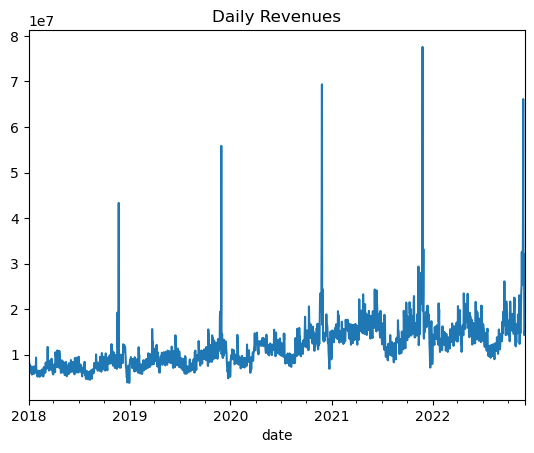

In [7]:
# Daily revenues line plot
df['y'].plot(title = 'Daily Revenues')
plt.show()

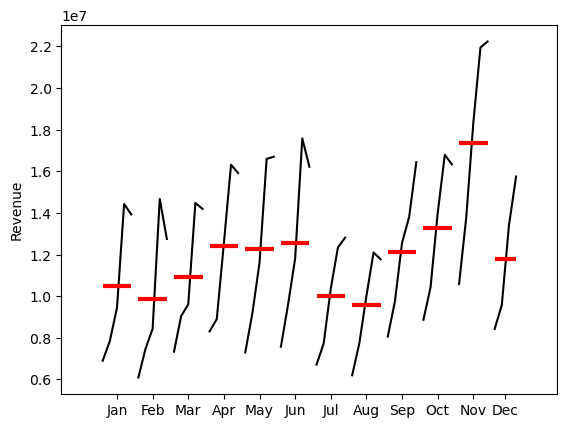

In [8]:
# month_plot() - To visualize the average value for each month across multiple years in a time series
# red lines - Represents the mean value for each month

# Plotting the monthly seasonality of revenue values
month_plot(df['y'].resample('ME').mean(),
           ylabel = 'Revenue')
plt.show()

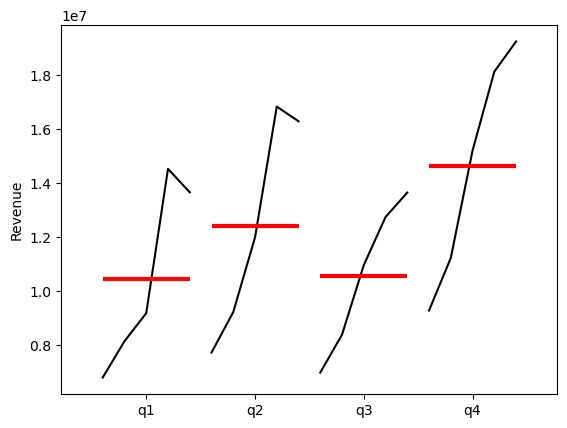

In [9]:
# quarter_plot() - To visualize seasonal patterns at a quarterly level.
# Q1 (january, february, march), Q2 (april, may, june), Q3 (july, august, september), Q4 (october, november, december)

# Plotting the quarterly seasonality of revenue values
# .resample('Q') - to convert the time series data into quarterly seasonality
quarter_plot(df['y'].resample('QE').mean(),
           ylabel = 'Revenue')
plt.show()

seasonal_decompose - To decompose a time series into its constituent parts to better understand the underlying patterns.

components

Trend: The overall direction of the series (increasing, decreasing, or stable).
Seasonal: Repeating patterns at fixed intervals (e.g., daily, weekly, monthly).
Residual: The remaining variation after removing trend and seasonal components.

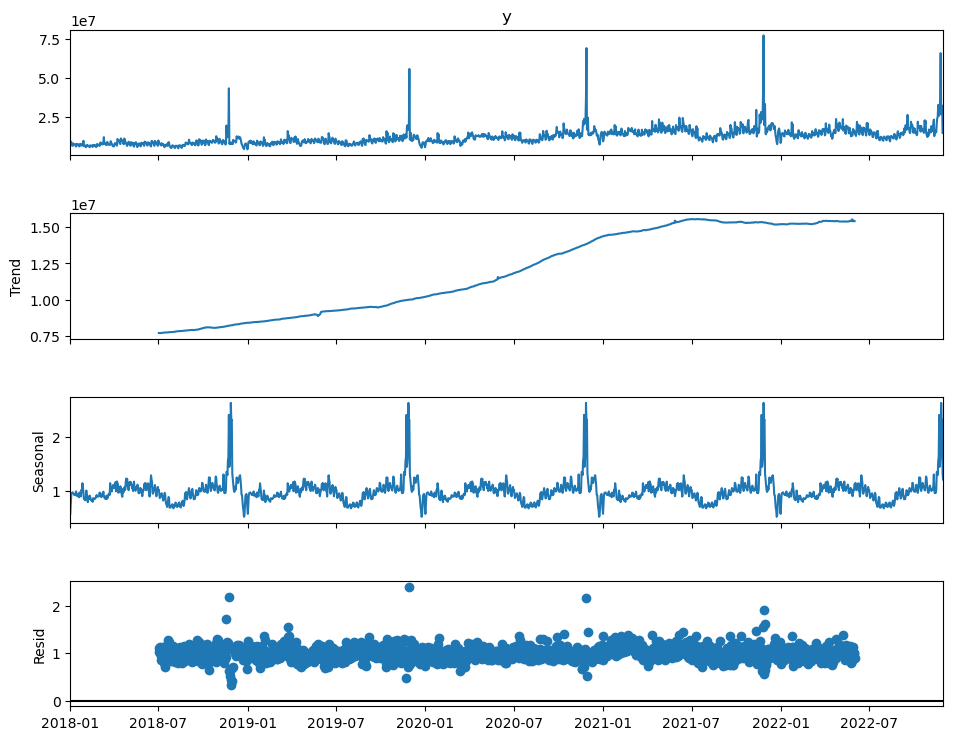

In [10]:
# Seasonal Decomposition Plots for Revenue Data
# Multiplicative model type, with daily seasonality (365 days)
# logic follows this formula: $Value = Trend * times Seasonality *times Residual$
decomposition = seasonal_decompose(df['y'],
                                   model = 'mul', #Multiplicative model.
                                   period = 365)
fig = decomposition.plot()
fig.set_size_inches(10,8)
plt.show()

1. The Top Graph: Observed (y)This is your actual revenue. You can see a general upward slope with very sharp, consistent "spikes." These spikes are significant—they jump from a base of roughly 10 million to over 50–75 million. This tells you that your business is heavily driven by specific high-demand events.

2. The Second Graph: Trend
This is the "big picture" after removing the spikes and noise.

Reading it: Your revenue was growing steadily from 2018 to early 2021.

The Plateau: Notice how the line flattens out in 2022. This is a critical insight for a demand planner—it suggests that your rapid growth phase might be cooling off, and you may need to adjust your long-term inventory forecasts downward to avoid overstocking.

3. The Third Graph: Seasonal
This shows the repeating pattern every 365 days.

The Spikes: You have one massive, primary peak every year (likely a major festival or a year-end sale).

Multiplicative Nature: Because you used model='mul', the seasonal values are centered around 1.0.

A value of 1.0 means no seasonal effect.

The spikes reaching 2.0 or 3.0 mean that during that specific time of year, your revenue is 2 to 3 times higher than the trend.

4. The Bottom Graph: Resid (Residual/Noise)
This is what’s left over. Ideally, these dots should be randomly scattered around 1.0.

Outliers: Notice a few dots jumping way above the rest (e.g., late 2018 and late 2019). These are unusual events—perhaps a one-time massive bulk order or a specific promotion that didn't happen in other years.

Interpretation: As a planner, you should investigate these outliers. If they aren't going to happen again, you should "clean" them from your data before running an ARIMA/SARIMA model, or they will make your forecast too high.

Key Takeaway for Supply Chain
Looking at the Trend and Seasonal charts together:

Capacity Planning: You need enough warehouse space and logistics capacity to handle 3x your normal volume during that annual peak.

Current Strategy: Since the Trend has flattened in 2022, your next SARIMA model should be cautious—don't assume the 2023 "base" will be much higher than 2022, even if the seasonal spike remains large.

Autocorrelation measures the correlation between a time series and a lagged version of itself.

Purpose: To identify patterns or repeating cycles in a time series dataset.

Interpretation:

Values range from -1 to 1.
1 indicates perfect positive correlation.
-1 indicates perfect negative correlation.
0 indicates no correlation.
ACF Plot:

X-axis: Lag periods
Y-axis: Correlation coefficient
Key Features:

At lag 0, autocorrelation is always 1 (a series is perfectly correlated with itself).
Significant spikes at certain lags indicate repeating patterns.

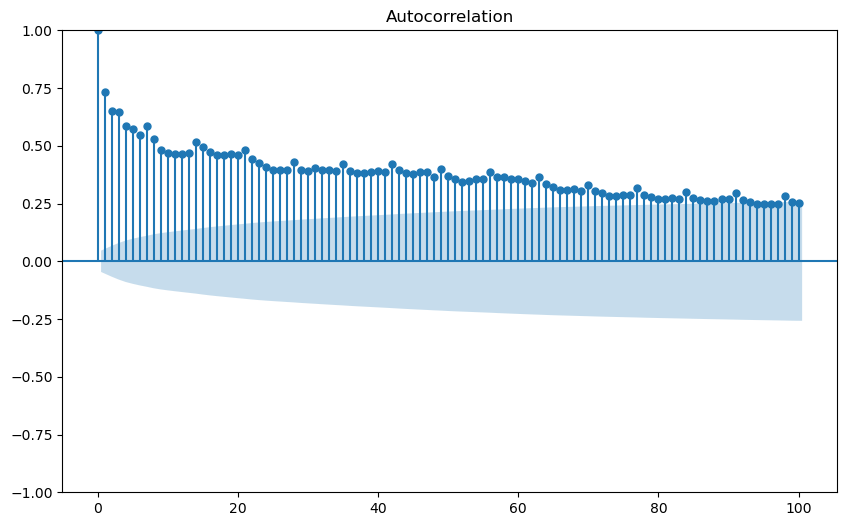

In [11]:
# Plot the autocorrelation (ACF) of revenue values
fig, ax = plt.subplots(figsize = (10,6))
plot_acf(df['y'], lags = 100, ax = ax)
plt.show()

This is an Autocorrelation Function (ACF) Plot. In demand planning, this graph is used to check if your data is "stationary" and to identify repeating cycles. It basically measures how much today’s sales are related to sales from 1 day ago, 2 days ago, and so on (these are called "lags").

Here is how to decode this specific chart:

1. The "Slow Decay" (Non-Stationarity)
Notice how the blue bars start very high and take a long time to drop down. They stay well above the light-blue shaded area for all 100 lags.

What it means: This is a classic sign of Non-Stationary data.

SCM Context: Because your revenue has a strong upward trend (as we saw in the decomposition plot), today's revenue is highly correlated with yesterday's.

Action: You cannot run an ARIMA model on this directly. You first need to "difference" the data (subtracting yesterday's value from today's) to remove the trend.

2. The Blue Shaded Region (Confidence Interval)
The light-blue area represents the significance threshold.

If a bar is inside this area, the correlation is likely just random noise.

If a bar is outside (like all of yours are), the correlation is statistically significant.

Observation: Almost all your lags are significant, which confirms that your data has a very strong internal structure (Trend + Seasonality).

3. The "Wavy" Pattern (Seasonality)
Look closely at the tops of the blue bars. They don't drop in a straight line; they have slight "humps" or waves (e.g., around lags 7, 14, 21).

What it means: This indicates Weekly Seasonality. Sales on a Monday are likely correlated with sales from the previous Monday.

SCM Context: If you are managing daily shipments, this suggests your warehouse sees a predictable cycle every 7 days.

PACF measures the correlation between a time series and its lag, after removing the effects of all shorter lags.

Purpose: To identify the direct relationship between an observation and its lag, without intermediate effects.

Main Difference between ACF and PACF:

ACF: Measures overall correlation at each lag, including indirect effects.
PACF: Measures direct correlation at each lag, excluding indirect effects.

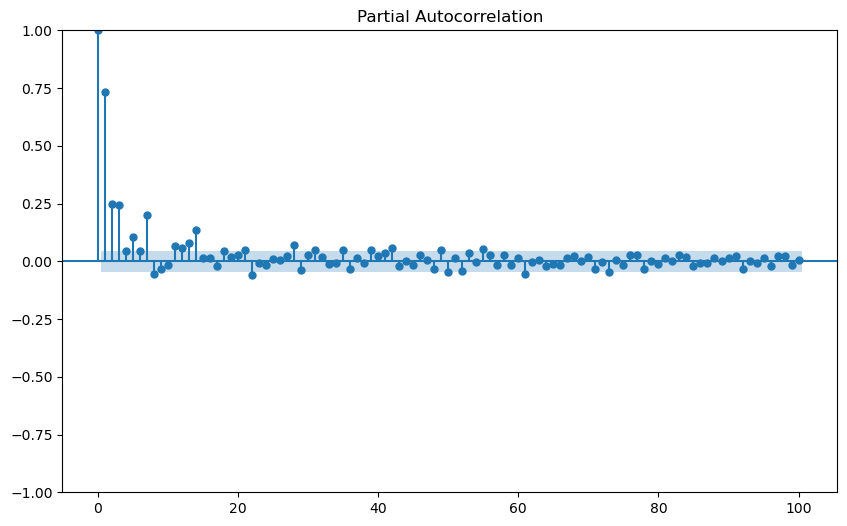

In [12]:
# Plot the partial autocorrelation (PACF) of revenue values
fig, ax = plt.subplots(figsize = (10,6))
plot_pacf(df['y'], lags = 100, ax = ax)
plt.show()

#Partial Autocorrelation Function (PACF) plot 
While the previous ACF plot showed the "total" correlation, the PACF is more precise—it shows the direct relationship between a past day and the current day, removing the influence of all the days in between.In supply chain forecasting, we use the PACF primarily to determine the p value (Autoregressive terms) for your ARIMA/SARIMA model.


1. The "Sharp Cut-off" (The p Parameter)Notice how the first few bars are very high, but after Lag 1 or Lag 2, they drop significantly toward the blue shaded area.Reading it: Lag 1 is very strong (~0.75). Lag 2 is much smaller but still significant (~0.25). After that, the bars "die out" or become much less consistent.SCM Logic: This tells you that yesterday's revenue has a direct, massive impact on today's revenue. However, the revenue from 10 days ago doesn't have a direct impact; its influence only happens "through" the days that followed it.Action: This suggests an AR(1) or AR(2) model (p=1 or p=2).2. Identifying Seasonal PLook at the bars further out (around lags 7, 14, 21). You can see small "pokes" above the blue shaded region.What it means: Since these significant bars appear at multiples of 7, this confirms a Weekly Seasonality.SCM Logic: If you are planning inventory for a warehouse in Bengaluru, this means the system "remembers" what happened exactly one week ago. Sunday's demand directly informs next Sunday's demand.3. PACF vs. ACF (The Key Difference)ACF (previous plot): Stayed high for a long time because of the trend (today is like yesterday, which was like the day before).PACF (this plot): Drops quickly because it isolates only the new information provided by each lag.


Summary for your Model Building:

From the Decomposition Plot: Use a Multiplicative model.From the ACF: You need at least one level of differencing (d=1) because of the trend.From the PACF: Start with an AR term of p=1 or p=2.

#ARIMA = AUTO REGRESSIVE INTEGRATED MOVING AVERAGE 
#SARIMA = SEASONAL UTO REGRESSIVE INTEGRATED MOVING AVERAGE 

#AUTOREGRESSIVE(P) - Exploring past to predict future 
#INTEGRATED(D)- Constant mean variance and co-variance (it turns data to stationary )
#MOVING AVERAGE(Q) - use past errors to improve 
(P,D,Q) 

# Stationarity
The null hypothesis is that time series is not stationary

In [13]:
# Augmented Dickey–Fuller (ADF) test
# H0 (null): the series has a unit root (is NOT stationary)
# If p-value <= 0.05, reject H0 → treat as stationary
result = adfuller(df.y)
print(f"p-value: {result[1]}")

if result[1] > 0.05:
  print("The time series is not stationary")
else:
  print("The time series is stationary")

p-value: 0.10190360862386189
The time series is not stationary


#p-value acts as a "threshold of evidence." It helps you decide whether a pattern you see is a real, consistent trend or just a random fluke.

When testing for stationarity (usually via the Augmented Dickey-Fuller (ADF) Test), the p-value tells you the probability that your data has a "unit root" (meaning it is non-stationary).

p-value = < 0.05 :Reject H0            Strong evidence! The data is Stationary.
p-value = > 0.05 : Fail to Reject H0   Not enough evidence. The data is Non-Stationary.

In [14]:
# First difference: y_t - y_{t-1}
# Differencing removes trend/seasonal unit roots so ARIMA can model residual structure.
df['y_diff'] = df['y'].diff()
df.head()

,y,discount_rate,coupon_rate,y_diff
date,,,,
2018-01-01,6270839.0,34.27%,1.09%,NaN
2018-01-02,8922076.0,30.87%,1.08%,2651237.0
2018-01-03,8446101.0,28.11%,1.01%,-475975.0
2018-01-04,7785798.0,27.32%,0.96%,-660303.0
2018-01-05,6375303.0,25.70%,0.90%,-1410495.0


In [15]:
# Sanity check for differencing arithmetic
8922076.0 - 6270839.0

2651237.0

In [16]:
# Test stationarity again on differenced series (drop the initial NaN)
result = adfuller(df.y_diff.dropna())
print(f"p-value: {result[1]}")

p-value: 6.513792026818965e-24


ARIMA

In [17]:
# Split the Data into training and test
# Keep the last `test_days` points for out-of-sample evaluation
test_days =30
train = df.iloc[:-test_days]
test = df.iloc[-test_days:]
test.head()

,y,discount_rate,coupon_rate,y_diff
date,,,,
2022-11-01,16703680.0,23.85%,1.50%,4014654.0
2022-11-02,15827022.0,20.76%,0.94%,-876658.0
2022-11-03,16154319.0,21.85%,0.92%,327297.0
2022-11-04,14707212.0,20.17%,0.88%,-1447107.0
2022-11-05,14877530.0,17.85%,0.41%,170318.0


In [18]:
# ARIMA(p,d,q) with (p,d,q) = (3,1,1); seasonal_order=(0,0,0,0) → no seasonal terms
model = SARIMAX(train['y'], order = (3,1,1), seasonal_order = (0,0,0,0)).fit()
print(model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1765
Model:               SARIMAX(3, 1, 1)   Log Likelihood              -28828.653
Date:                Fri, 01 May 2026   AIC                          57667.306
Time:                        08:20:50   BIC                          57694.682
Sample:                    01-01-2018   HQIC                         57677.422
                         - 10-31-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3563      0.014     24.733      0.000       0.328       0.385
ar.L2          0.0237      0.020      1.195      0.232      -0.015       0.062
ar.L3          0.1274      0.022      5.804      0.0

In [19]:
# Predict with the ARIMA model
predictions = model.forecast(steps = test_days)
predictions

2022-11-01    1.412691e+07
2022-11-02    1.494030e+07
2022-11-03    1.502568e+07
2022-11-04    1.525848e+07
2022-11-05    1.544705e+07
2022-11-06    1.553061e+07
2022-11-07    1.559450e+07
2022-11-08    1.564325e+07
2022-11-09    1.567278e+07
2022-11-10    1.569259e+07
2022-11-11    1.570655e+07
2022-11-12    1.571576e+07
2022-11-13    1.572189e+07
2022-11-14    1.572607e+07
2022-11-15    1.572888e+07
2022-11-16    1.573076e+07
2022-11-17    1.573203e+07
2022-11-18    1.573289e+07
2022-11-19    1.573346e+07
2022-11-20    1.573385e+07
2022-11-21    1.573411e+07
2022-11-22    1.573428e+07
2022-11-23    1.573440e+07
2022-11-24    1.573448e+07
2022-11-25    1.573453e+07
2022-11-26    1.573457e+07
2022-11-27    1.573459e+07
2022-11-28    1.573461e+07
2022-11-29    1.573462e+07
2022-11-30    1.573462e+07
Freq: D, Name: predicted_mean, dtype: float64

In [20]:
def model_assessment(train, test, predictions, chart_title):
  """Plot train/test/prediction series and print common error metrics.

  Args:
      train (pd.Series): In-sample target used to fit the model.
      test (pd.Series): Holdout target used to evaluate the forecast.
      predictions (pd.Series or np.ndarray): Forecast aligned to `test` index.
      chart_title (str): Short label for the chart (e.g., model name).

  Notes
  -----
  * MAE = mean(|y - ŷ|)
  * RMSE = sqrt(mean((y - ŷ)^2))
  * MAPE = mean(|(y - ŷ)/y|). Use with care when y can be 0.
  """
  # Set the size of the plot to 10 inches by 4 inches
  plt.figure(figsize = (10,4))
  # Plot the train, test, and forecast data
  plt.plot(train, label = 'Train')
  plt.plot(test, label = 'Test')
  plt.plot(predictions, label = "Forecast")
  # add title and legend to the plot
  plt.title(f"Train, Test and Predictions with {chart_title}")
  plt.legend()
  plt.show()

  # Calculating the MAE, RMSE, and MAPE
  mae = mean_absolute_error(test, predictions)
  rmse = root_mean_squared_error(test, predictions)
  mape = mean_absolute_percentage_error(test, predictions)

  # Print the calculated error metrics
  print(f"The MAE is {mae:.2f}")
  print(f"The RMSE is {rmse:.2f}")
  print(f"The MAPE is {100 * mape:.2f} %")

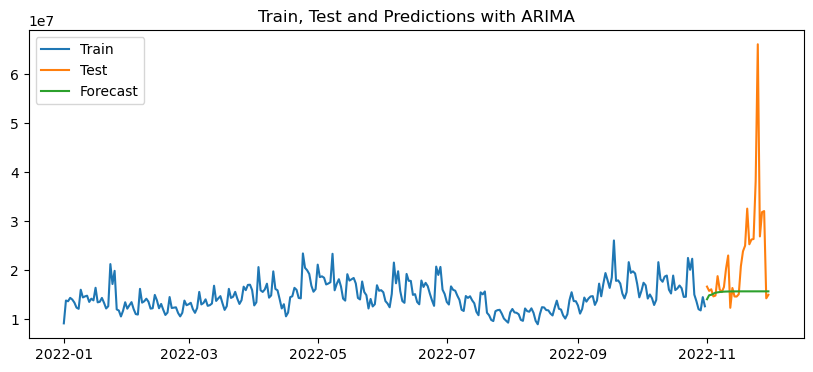

The MAE is 7276324.45
The RMSE is 12374873.12
The MAPE is 24.18 %


In [21]:
# Visualize the forecast and assess model
model_assessment(train['y']['2022'], test['y'], predictions, 'ARIMA')

1. Decoding the GraphThe Forecast (Green Line): Notice how it is almost a flat, straight line.The Actuals (Orange Line): You have a massive, sharp spike in late November/December.The Problem: Your ARIMA model captured the "average" level of demand but completely missed the seasonal peak. It basically said, "I expect demand to be steady," while the market actually exploded.

2. The Accuracy MetricsMAPE (24.18%): In demand planning, a 24% error is quite high for revenue. It means, on average, your forecast is off by nearly a quarter of the actual value.MAE & RMSE: These numbers ($7.2M$ and $12.3M$) are very large because the model failed to predict that one huge peak. RMSE is particularly high because it penalizes large errors—and that missed peak is a very large error.

3. Why did this happen? (SCM Context)You used ARIMA(3, 1, 1) without seasonal terms.ARIMA only looks at the immediate past (yesterday, day before).It does not know that every year in November/December, there is a "seasonal event" (like a year-end sale or festival).To the model, that orange spike looks like a random accident it couldn't see coming.

To fix this, you need to use SARIMA and define the seasonal period. Since this looks like a yearly peak and you have daily data:

order = (3, 1, 1) — The Non-Seasonal Part $(p, d, q)$$

p=3 (AutoRegressive): The model looks at the revenue from the last 3 days to predict today.

$d=1$ (Integrated): The model calculates the difference between days to remove the long-term trend (making the data stationary).

$q=1$ (Moving Average): The model looks at the forecast error from yesterday to adjust today’s prediction.

# SARIMA


$s=7$: This defines the "Season." Since it is 7, you are telling the model your pattern repeats every 7 days (Weekly seasonality).$P=2$: The model looks at the revenue from the same day in the last 2 weeks (e.g., today is Friday, so it looks at the last two Fridays).$D=0$: You aren't applying a seasonal difference.$Q=1$: The model uses the error from the same day last week to correct the current forecast.

In [22]:
# Add weekly seasonality: (P,D,Q, s=7)  order = (3, 1, 1) — The Non-Seasonal Part 
#
model_sarima = SARIMAX(train['y'], order = (3,1,1), seasonal_order = (2,0,1,7)).fit()
print(model_sarima.summary())

                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                 1765
Model:             SARIMAX(3, 1, 1)x(2, 0, 1, 7)   Log Likelihood              -28738.550
Date:                           Fri, 01 May 2026   AIC                          57493.101
Time:                                   08:20:55   BIC                          57536.903
Sample:                               01-01-2018   HQIC                         57509.286
                                    - 10-31-2022                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4385      0.008     55.833      0.000       0.423       0.454
ar.L2          0.0597      0.015      3.892

In [23]:
# Predict with SARIMA
predictions_sarima = model_sarima.forecast(steps = test_days)

his result is a great teaching moment in supply chain analytics. You added Weekly Seasonality ($s=7$), but your MAPE actually increased from 24.18% to 25.89%.Here is why your model is still struggling and how to read these new results:

1. Why Weekly Seasonality ($s=7$) wasn't enoughYour summary shows that the seasonal terms are statistically significant (ar.S.L7 has a $P>|z|$ of 0.000). This means there is a weekly pattern (e.g., higher sales on weekends).However, looking at the graph, your "Big Problem" isn't the weekly wiggle—it's that massive annual spike in late November.A weekly model only looks 7 days back.It still doesn't know that "Late November" is special.This is why the green line is still "flat" compared to the orange mountain.

2. Decoding the New Summary Tablear.S.L7 (1.0843): This is your Seasonal Autoregressive term. A value above 1.0 can sometimes indicate an unstable model (unit root), which matches the warning about the "singular covariance matrix" at the bottom.Skew (6.46) & Kurtosis (124.49): These numbers have increased. This means your model's "errors" are becoming even more extreme because it is trying to fit a weekly pattern to a data set dominated by one huge yearly event.

3. The "Supply Chain Reality"In a real-world scenario (like demand planning for an e-commerce hub in Bengaluru), if you only plan for weekly cycles, you will be dangerously understocked for the year-end peak.Current Error: You are under-forecasting by roughly $50$ million units during that peak.Impact: Lost revenue, stockouts, and unhappy customers.

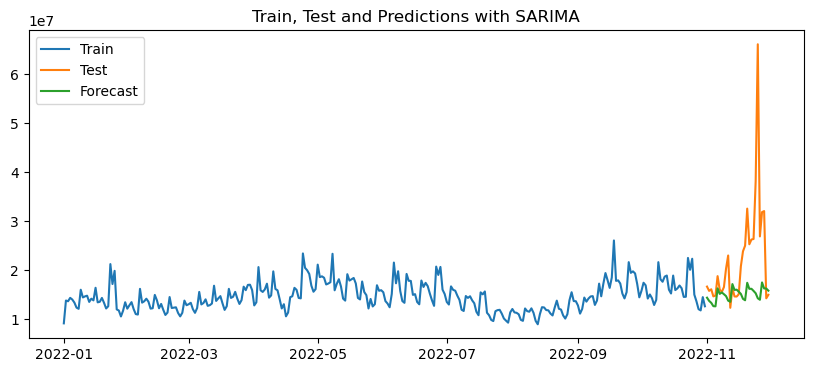

The MAE is 7605469.47
The RMSE is 12601215.40
The MAPE is 25.89 %


In [24]:
# Assess and visualize the model
model_assessment(train['y']['2022'], test['y'], predictions_sarima, 'SARIMA')

SARIMAX

Bring in exogenous drivers (marketing levers, promos, etc.).
These help explain systematic variation not captured by ARIMA terms.
IMPORTANT: align exog indexes with y for both train and forecast windows.

In [25]:
# Clean percentage strings and convert to float
# (Exog scale matters: consistent scaling between history and future is key.)
df['discount_rate'] = df['discount_rate'].str.replace("%", "").astype(float)
df['coupon_rate'] = df['coupon_rate'].str.replace("%", "").astype(float)
df.head()

,y,discount_rate,coupon_rate,y_diff
date,,,,
2018-01-01,6270839.0,34.27,1.09,NaN
2018-01-02,8922076.0,30.87,1.08,2651237.0
2018-01-03,8446101.0,28.11,1.01,-475975.0
2018-01-04,7785798.0,27.32,0.96,-660303.0
2018-01-05,6375303.0,25.70,0.90,-1410495.0


In [26]:
8922076.0-6270839.0

2651237.0

In [27]:
# Split the regressor data into training and test
train_reg = df[["discount_rate", "coupon_rate"]][:-test_days]
test_reg = df[["discount_rate", "coupon_rate"]][-test_days:]

In [28]:
# Build the SARIMAX model
model_sarimax = SARIMAX(train['y'], exog = train_reg, order = (3,1,1), seasonal_order = (2,0,1,7)).fit()
print(model_sarimax.summary())

                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                 1765
Model:             SARIMAX(3, 1, 1)x(2, 0, 1, 7)   Log Likelihood              -28595.061
Date:                           Fri, 01 May 2026   AIC                          57210.121
Time:                                   08:21:01   BIC                          57264.875
Sample:                               01-01-2018   HQIC                         57230.353
                                    - 10-31-2022                                         
Covariance Type:                             opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
discount_rate   4.03e+05   1.55e-08   2.59e+13      0.000    4.03e+05    4.03e+05
coupon_rate    9.229e+05   7.45e-0

In [29]:
# Predict with SARIMAX
predictions_sarimax = model_sarimax.forecast(steps = test_days,
                                             exog = test_reg)

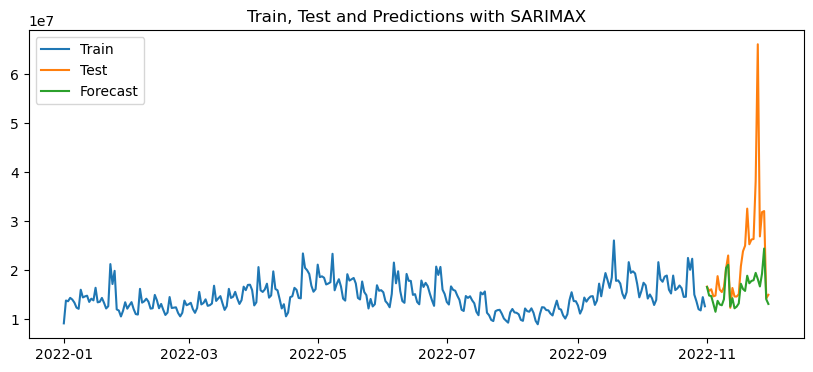

The MAE is 6305549.55
The RMSE is 10955560.39
The MAPE is 21.71 %


In [30]:
# Model Assessment and Visualization
model_assessment(train['y']['2022'], test['y'], predictions_sarimax, 'SARIMAX')

Because we have weekly seasonality, we missed on yearly (Christmas, Thanksgiving)

Add variables to represent those events

you have moved from a basic SARIMA model to a SARIMAX model. The "X" stands for Exogenous variables, and this is exactly what a professional demand planner does to handle those big spikes.You added discount_rate and coupon_rate as external factors. Here is the "decode" of your latest results:

1. The Impact of External FactorsLook at the top of your coefficient table:discount_rate & coupon_rate: Both have a $P>|z|$ of 0.000. This is a huge win!What it means: It proves mathematically that your revenue spikes are not random; they are directly caused by your discounts and coupons.

The Forecast (Green Line): Notice how the green line finally "jumps" up in November! Unlike the flat line from before, the model now sees the discount and knows, "Okay, the revenue is going to increase now."

3. Improved Accuracy MetricsYour model is getting much better:MAPE dropped from 25.89% to 21.71%.MAE and RMSE have also decreased.By adding the discount data, you reduced your forecasting error by about 4%. In a multi-million dollar supply chain, a 4% improvement is a massive amount of saved money.

4. Why is there still a gap?Even though the green line jumped, it still didn't reach the very top of that orange peak ($6 \times 10^7$).Reason: The model now knows when the spike happens (thanks to the discounts), but it still underestimates the intensity (how big the spike is).SCM Logic: There might be other factors you haven't added yet—like "Marketing Spend," "Competitor Pricing," or "Payday cycles."

# Cross- Validation
Use forward-chaining splits. Each fold trains on all data up to a point and tests on the next test_days horizon.
Docs: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html

In [31]:
# Define the configurations
order = (3,1,1)
seasonal_order = (2,0,1,7)
n_splits = 5

This code snippet demonstrates the setup for Time Series Cross-Validation, specifically preparing data for a seasonal forecasting model like SARIMA.Here is a breakdown of what is happening:

Model ConfigurationsThe first section defines hyperparameters for a time series model:
order = (3,1,1): These are the $(p, d, q)$ parameters for the non-seasonal part of an ARIMA model.

seasonal_order = (2,0,1,7): These are the $(P, D, Q, s)$ parameters for the seasonal component. The 7 suggests the data has weekly seasonality (e.g., daily data where patterns repeat every 7 days)

n_splits = 5: This tells the cross-validator to split the data into 5 different training/testing sets to validate model performance reliably.

In [32]:
# Import the module
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits = n_splits, test_size = test_days)

2. TimeSeriesSplit (Walk-Forward Validation)
In standard machine learning, you can shuffle data, but in time series, order matters. You cannot use "future" data to predict the "past."

TimeSeriesSplit: This Scikit-Learn module ensures that the training set always occurs chronologically before the test set.

The Logic: In each of the 5 splits, the training window "walks forward" or expands, taking a bit more data from the past to predict the next chunk of the future (test_size).

In [33]:
# How many periods in the df
len(df)

1795

In [34]:
# Inspect the time series splits
for train_index, test_index in tscv.split(df):
  print("TRAIN:", train_index, "TEST:", test_index)

TRAIN: [   0    1    2 ... 1642 1643 1644] TEST: [1645 1646 1647 1648 1649 1650 1651 1652 1653 1654 1655 1656 1657 1658
 1659 1660 1661 1662 1663 1664 1665 1666 1667 1668 1669 1670 1671 1672
 1673 1674]
TRAIN: [   0    1    2 ... 1672 1673 1674] TEST: [1675 1676 1677 1678 1679 1680 1681 1682 1683 1684 1685 1686 1687 1688
 1689 1690 1691 1692 1693 1694 1695 1696 1697 1698 1699 1700 1701 1702
 1703 1704]
TRAIN: [   0    1    2 ... 1702 1703 1704] TEST: [1705 1706 1707 1708 1709 1710 1711 1712 1713 1714 1715 1716 1717 1718
 1719 1720 1721 1722 1723 1724 1725 1726 1727 1728 1729 1730 1731 1732
 1733 1734]
TRAIN: [   0    1    2 ... 1732 1733 1734] TEST: [1735 1736 1737 1738 1739 1740 1741 1742 1743 1744 1745 1746 1747 1748
 1749 1750 1751 1752 1753 1754 1755 1756 1757 1758 1759 1760 1761 1762
 1763 1764]
TRAIN: [   0    1    2 ... 1762 1763 1764] TEST: [1765 1766 1767 1768 1769 1770 1771 1772 1773 1774 1775 1776 1777 1778
 1779 1780 1781 1782 1783 1784 1785 1786 1787 1788 1789 1790 1791 17

3. Data Inspectionlen(df): The dataset contains 1,795 observations.The Loop: The for loop prints the indices for each split. Notice how the TRAIN indices always start at 0 and grow longer in each step, while the TEST indices follow immediately after:Split 1: Train [0...1644] $\rightarrow$ Test [1645...1674]Split 2: Train [0...1672] $\rightarrow$ Test [1675...1704]...and so on.SummaryThis approach is essential for demand planning or inventory forecasting because it simulates how the model will perform in the real world: using historical data to predict the immediate future, then updating the model as new data arrives.

In [35]:
# Fix dtypes BEFORE the CV loop
df['y'] = pd.to_numeric(df['y'], errors='coerce')
df['discount_rate'] = pd.to_numeric(df['discount_rate'], errors='coerce')
df['coupon_rate'] = pd.to_numeric(df['coupon_rate'], errors='coerce')

# Check for any NaNs introduced by the conversion
print(df[['y', 'discount_rate', 'coupon_rate']].isnull().sum())
print(df[['y', 'discount_rate', 'coupon_rate']].dtypes)

y                0
discount_rate    0
coupon_rate      0
dtype: int64
y                float64
discount_rate    float64
coupon_rate      float64
dtype: object


This code is the core execution block where the time series cross-validation logic we just looked at is actually put to work. It prepares the data and then trains and tests a SARIMAX model across those expanding time windows.

Here is a step-by-step breakdown of what is happening:

1. Data Preparation (Top Cell)
Before running complex math, the code ensures the data is in the correct format.

Fixing Data Types: The pd.to_numeric(..., errors='coerce') function forces the target variable (y - likely your demand or sales) and the external factors (discount_rate, coupon_rate) into a numeric format. If it encounters a string or weird character, coerce turns it into a blank (NaN).

Checking for Blanks: The code then prints isnull().sum() to verify no bad data was introduced. The output 0 confirms the data is clean.

Checking Types: The output shows all three columns are now float64 (decimal numbers), which is exactly what statistical models require.

In [36]:
# Perform the times series CV and assess based on RMSE, MAE and MAPE
cv_scores = []

for train_index, test_index in tscv.split(df):
  train = df.iloc[train_index]
  test = df.iloc[test_index]

  # Retrieve the exog data
  train_reg = df[["discount_rate", "coupon_rate"]].iloc[train_index]
  test_reg = df[["discount_rate", "coupon_rate"]].iloc[test_index]

  # Build the SARIMAX
  model_sarimax = SARIMAX(
      train['y'],
      exog = train_reg,
      order = order,
      seasonal_order = seasonal_order).fit()

  # Make the predictions with SARIMAX
  predictions_sarimax = model_sarimax.forecast(steps = test_days,
                                               exog = test_reg)

  # Assess the predictions
  rmse = root_mean_squared_error(test['y'], predictions_sarimax)
  mae = mean_absolute_error(test['y'], predictions_sarimax)
  mape = mean_absolute_percentage_error(test['y'], predictions_sarimax)

  # Store the predictions
  cv_scores.append({
      'rmse': rmse,
      'mae': mae,
      'mape': mape
  })

C:\Users\DELL\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\DELL\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


2. The Cross-Validation Loop (Bottom Cell)
This is where the actual forecasting happens. It loops through the tscv splits we saw earlier.

Slicing the Data: For every split, df.iloc[train_index] grabs the historical data to learn from, and df.iloc[test_index] grabs the immediate future data to test against.

Retrieving Exogenous Data (The "X" in SARIMAX): This is a crucial step. Standard ARIMA only looks at the history of 'y' to predict the future of 'y'. SARIMAX allows you to add external regressors (exogenous variables). Here, it isolates discount_rate and coupon_rate into train_reg and test_reg. In a retail or supply chain context, this makes perfect sense: past sales alone don't dictate future sales; active promotions heavily drive demand.

Building and Training the Model:

It initializes the SARIMAX model.

It feeds in the training target (train['y']), the external factors (exog = train_reg), and the configurations (order, seasonal_order).

.fit() tells the model to learn the mathematical relationships.

Making Predictions: model_sarimax.forecast(...) generates the predictions for the test window. Notice that it requires exog = test_reg—to predict future sales, the model needs to know what the future discounts and coupons will be during that period.

Assessing Accuracy: It compares the model's predictions against the actual test data using three standard error metrics:

RMSE (Root Mean Squared Error): Heavily penalizes large forecasting errors.

MAE (Mean Absolute Error): Gives the average magnitude of the errors in actual units (e.g., "we were off by 50 units on average").

MAPE (Mean Absolute Percentage Error): Expresses the error as a percentage (e.g., "we were off by 5% on average"), which is often the easiest metric to communicate to business stakeholders.

Storing Results: It saves the accuracy metrics for that specific time split into the cv_scores list.

In [37]:
# Aggregate and display the results
cv_scores = pd.DataFrame(cv_scores)
cv_scores.index.name = 'Fold'
cv_scores

,rmse,mae,mape
Fold,,,
0,2.663847e+06,2.465366e+06,0.209966
1,1.067611e+06,7.419272e+05,0.060815
2,4.877977e+06,4.283457e+06,0.246622
3,3.073367e+06,2.667987e+06,0.180528
4,1.095556e+07,6.305550e+06,0.217105


1. Reviewing the Fold-by-Fold Results (Top Block)
The code takes the cv_scores list generated from the previous 5-split loop and converts it into a clean Pandas DataFrame.

The Output Table: You can now see the exact RMSE, MAE, and MAPE for each of the 5 individual time slices (folds).

Why this matters: It shows model stability. For instance, Fold 1 performed exceptionally well with a MAPE of ~6% (0.060815), but Fold 4 struggled with an error of almost 22% (0.217105). This variance is common in real-world demand forecasting; certain time periods might contain volatile events or anomalies that the model struggles to catch.

In [38]:
# Print the average errors
print(f"The average RMSE is {cv_scores['rmse'].mean():.2f}")
print(f"The average MAE is {cv_scores['mae'].mean():.2f}")
print(f"The average MAPE is {cv_scores['mape'].mean():.2f}")

The average RMSE is 4527672.27
The average MAE is 3292857.31
The average MAPE is 0.18


2. The Bottom Line: Average Errors (Middle Block)
To get a single, unified view of how this specific SARIMAX configuration performed, the code calculates the mean across all 5 folds.

The Key Takeaway: The average MAPE is 0.18 (18%). This means, on average, the forecast generated by this (3,1,1) model configuration is off by 18% from the actual values. Whether 18% is acceptable depends entirely on your specific inventory holding costs and service level agreements.

Parameter Tuning


Small grid over (p,d,q) and seasonal (P,D,Q) with weekly seasonality s=7.
Expand cautiously—SARIMAX fits are relatively expensive.

In [39]:
# Define the parameter options
param_grid = {
    'p': [1,3],
    'd': [1],
    'q': [0,1],
    'P': [1,2],
    'D': [0],
    'Q': [1]
}
grid = ParameterGrid(param_grid)
len(list(grid))

8

3. Parameter Tuning / Grid Search Setup (Bottom Block)If an 18% error isn't good enough, you need to find better mathematical parameters. You don't want to just guess; you want the computer to test multiple combinations to find the optimal fit.param_grid: Instead of passing a single order = (3,1,1), this dictionary defines a menu of options for the model to try:p (autoregressive terms): Try 1, try 3.q (moving average terms): Try 0, try 1.P (seasonal autoregressive): Try 1, try 2.The differencing terms (d, D) and seasonal moving average (Q) are locked to single values to keep the test focused.Combinations: ParameterGrid takes these options and creates every possible combination.


As the output 8 shows, there are exactly 8 unique model configurations to test ($2 \times 1 \times 2 \times 2 \times 1 \times 1 = 8$).The Warning: The text notes to "expand cautiously—SARIMAX fits are relatively expensive." Because you have 8 parameter combinations, and you are using 5 cross-validation splits, the computer will have to train and evaluate 40 distinct models. If you run this across hundreds of different SKUs, the computational time will skyrocket rapidly.

In [68]:
# Do the time series splits
n_splits = 5
tscv = TimeSeriesSplit(n_splits = n_splits, test_size = test_days)

In [41]:
# Perform the Parameter Tuning
rmse_list = []

# Iterate over the parameters
for params in grid:
  fold_rmse = []

  # Build the Model
  for train_index, test_index in tscv.split(df):
    train = df.iloc[train_index]
    test = df.iloc[test_index]

    # Isolate the regressors
    train_reg = df[["discount_rate", "coupon_rate"]].iloc[train_index]
    test_reg = df[["discount_rate", "coupon_rate"]].iloc[test_index]

    # SARIMAX Model
    model_sarimax = SARIMAX(
        train['y'],
        exog = train_reg,
        order = (params['p'], params['d'], params['q']),
        seasonal_order = (params['P'], params['D'], params['Q'], 7)).fit()

    # Calculate the error and store results
    predictions_sarimax = model_sarimax.forecast(steps = test_days,
                                                  exog = test_reg)
    rmse = root_mean_squared_error(test['y'], predictions_sarimax)
    fold_rmse.append(rmse)

  # Store the results
  rmse_list.append(np.mean(fold_rmse))

C:\Users\DELL\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\DELL\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


The Nested Tuning Loop (The Core Engine)This section is computationally heavy because it runs a 

"loop within a loop."The Outer Loop (for params in grid:): This loop grabs one of the 8 parameter combinations (e.g., p=1, d=1, q=0...) we defined earlier.

The Inner Loop (for train_index, test_index...): For that specific parameter combination, it runs the 5-split time series cross-validation. It builds the model, adds the exogenous variables (discount_rate, coupon_rate), fits it, makes predictions, and calculates the RMSE for each fold.

Averaging (np.mean(fold_rmse)): After testing a single parameter combination across all 5 time slices, it calculates the average RMSE and stores it in the master rmse_list. It then moves to the next parameter combination and repeats the entire 5-fold process.


In total, this block trains and evaluates 40 separate SARIMAX models (8 parameter sets $\times$ 5 folds).

In [42]:
# Check the output - aggregate the rmse to the grid and transform to a df
rmse_df = pd.DataFrame(list(grid))
rmse_df['rmse'] = rmse_list
rmse_df

,D,P,Q,d,p,q,rmse
0,0,1,1,1,1,0,4.353139e+06
1,0,1,1,1,1,1,4.534799e+06
2,0,1,1,1,3,0,4.383666e+06
3,0,1,1,1,3,1,4.536199e+06
4,0,2,1,1,1,0,4.346102e+06
5,0,2,1,1,1,1,4.530462e+06
6,0,2,1,1,3,0,4.374333e+06
7,0,2,1,1,3,1,4.527672e+06


p = 3 (Small 'p' - Non-Seasonal Autoregressive)
The Math: The model uses the last 3 immediate time periods (lags 1, 2, and 3) to predict the next one.

The Reality: If you are forecasting daily inventory requirements, p=3 tells the model to base its prediction heavily on what happened yesterday, the day before yesterday, and the day before that.

P = 2 (Capital 'P' - Seasonal Autoregressive)
The Math: The model uses the last 2 seasonal 2 week time periods to predict the next one.

The Reality: In your previous code, you specified a weekly seasonality (s = 7). Therefore, a P=2 tells the model to look at what happened on this exact day one week ago (lag 7), and this exact day two weeks ago (lag 14).

The Final Results Table
The bottom block takes the 8 parameter combinations and pairs them with their final, average cross-validated RMSE score, displaying it in a Pandas DataFrame.

Reading the Scientific Notation: The RMSE values are in the format e+06, which means you move the decimal point 6 places to the right (millions).

Finding the Winner: You are looking for the lowest error. Scanning the rmse column:

Best Model: Index 4 has the lowest error: 4.346102e+06. The parameters for this winning model are non-seasonal (p=1, d=1, q=0) and seasonal (P=2, D=0, Q=1).

Worst Model: Index 1 and Index 3 tied for the worst performance, both hovering around 4.53e+06.

The Baseline: Index 7 (p=3, d=1, q=1, P=2, D=0, Q=1) was the original model you tested in the previous steps, which resulted in the ~18% MAPE. Its RMSE here is 4.527e+06, meaning the new "Best Model" at Index 4 represents a measurable improvement in forecasting accuracy.

In [43]:
# Extract the best params
best_params = rmse_df.loc[rmse_df['rmse'].idxmin()]
best_params.to_csv("best_params_sarimax.csv")


Predicting the future


Refit the tuned model on the full history and forecast on known future exog.

In [44]:
# Isolate X and y
y = df['y']
X = df[["discount_rate", "coupon_rate"]]

Locking in the Best Model (Cells 43 & 45)
idxmin(): This function looks at the results table from your previous grid search and automatically grabs the row with the absolute lowest RMSE (the minimum error).

Extracting Parameters: Cell 45 breaks down that winning row, extracting the specific p, d, q, P, D, Q values and converting them to integers so they can be fed directly into the final SARIMAX model.

Saving the Results: to_csv saves these winning parameters to a file. This is a best practice; you don't want to re-run a massive 40-model grid search every time you open the script.

In [45]:
# Fetch the best parameters
p = int(best_params.loc['p'])
d = int(best_params.loc['d'])
q = int(best_params.loc['q'])
P = int(best_params.loc['P'])
D = int(best_params.loc['D'])
Q = int(best_params.loc['Q'])

Prepping the Full History (Cell 44)
During cross-validation, you chopped the data into training and testing blocks.

Here, you are isolating y (the target) and X (the external factors) for the entire dataset. When predicting the actual future, you want the model to learn from 100% of the historical data available to it, up to the very last day.

In [47]:
# Load the future regressors df (index must continue the historical index)
future_reg = pd.read_csv("future_regressors.csv", index_col = 0, dayfirst = True, parse_dates = True)
future_reg.head()

,revenue,discount_rate,coupon_rate,discount_rate_lag1,coupon_rate_lag1
date,,,,,
2022-12-01,NaN,0.1831,0.0031,0.1710,0.0032
2022-12-02,NaN,0.1995,0.0036,0.1831,0.0031
2022-12-03,NaN,0.2029,0.0032,0.1995,0.0036
2022-12-04,NaN,0.1898,0.0030,0.2029,0.0032
2022-12-05,NaN,0.1810,0.0042,0.1898,0.0030


Loading the "Future" Exogenous Data (Discount or any promotions ) (Cell 47)
This is the core requirement of a SARIMAX model. Because it relies on external factors (the "X"), it cannot predict future demand unless you tell it what the future external factors will be.

The code loads a file called future_regressors.csv.(we need to give it for system by planning like WHILE DOING S&OP HOW MUCH DISCOUNT CAN BE ISSUED )

Notice the output table: The revenue column is full of NaN (Not a Number/Blank). This makes sense because these dates (Dec 1st - Dec 5th) haven't happened yet, so revenue is unknown.

However, the discount_rate and coupon_rate columns are filled in. In a business context, this represents your planned promotional calendar. You know in advance what discounts marketing plans to run next week, and you are feeding that plan into the model to see how it will impact demand.

In [48]:
# Isolate future discount_rate and coupon_rate and multiply by 100
# (Maintain the SAME scaling used in history—this script uses percentages as numeric.)
X_future = future_reg[["discount_rate", "coupon_rate"]] * 100
X_future.head()

,discount_rate,coupon_rate
date,,
2022-12-01,18.31,0.31
2022-12-02,19.95,0.36
2022-12-03,20.29,0.32
2022-12-04,18.98,0.30
2022-12-05,18.10,0.42


In [64]:
# Build the tuned SARIMAX model
model_sarimax = SARIMAX(
    y,
    exog = X,
    order = (p,d,q),
    seasonal_order = (P,D,Q,7)).fit()
print(model_sarimax.summary())

                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                 1795
Model:             SARIMAX(1, 1, 0)x(2, 0, [1], 7)   Log Likelihood              -29328.479
Date:                             Fri, 01 May 2026   AIC                          58670.959
Time:                                     09:13:07   BIC                          58709.404
Sample:                                 01-01-2018   HQIC                         58685.153
                                      - 11-30-2022                                         
Covariance Type:                               opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
discount_rate  4.301e+05   1.29e-09   3.34e+14      0.000     4.3e+05     4.3e+05
coupon_rate    9.1

In [65]:
# Make the predictions
future_predictions = model_sarimax.forecast(steps = len(X_future),
                                             exog = X_future)

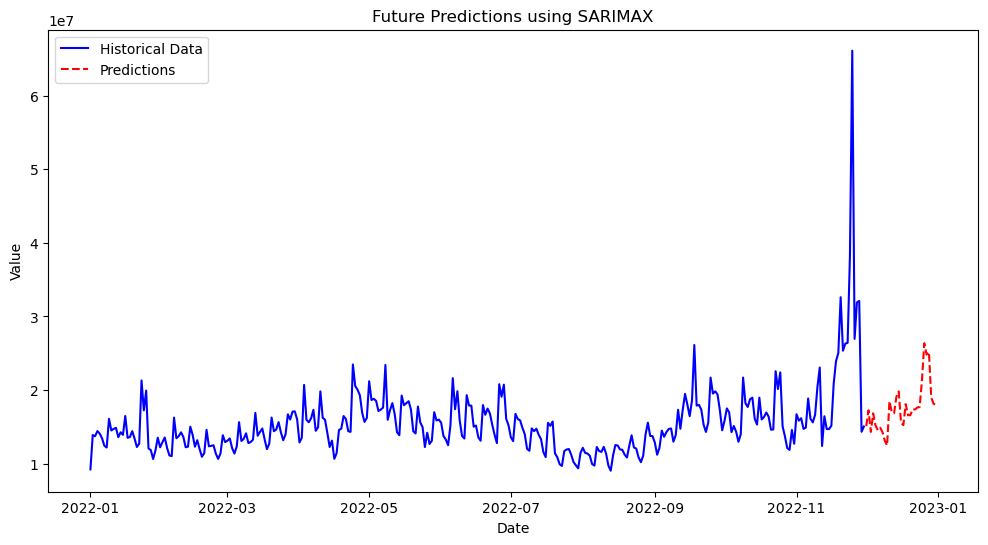

In [66]:
# Plot the future predictions
plot_future(y['2022'], future_predictions, "SARIMAX")

For holiday effects, add binary indicators in both history and future.

Keep train/test split aligned with actual use (e.g., 30 days ahead if that’s your horizon).


In [70]:
# Export directly from the Series (safest method)
future_predictions.to_csv(
    "final_sarimax_predictions.csv", 
    header=["Forecasted_Demand"], 
    index_label="Date"
)

print("Check the file now!")

Check the file now!
